![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver Insider Trading Research

This notebook studies whether insider dollar volume helps explain future returns

In [1]:
qb = QuantBook()
# Anchor the research clock to the start of 2026.
qb.set_start_date(2026, 1, 1)
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False

### Build an Insider Trading Universe

Select the 10 assets with the largest insider-trading dollar volume each day, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverInsiderTradingUniverse]) -> List[Symbol]:
    # Aggregate insider dollar volume per ticker and keep the 10 largest.
    dollar_volume: dict[Symbol, float] = {}
    for d in data:
        if not d.price_per_share:
            continue
        dollar_volume[d.symbol] = dollar_volume.get(d.symbol, 0) + (d.shares or 0) * d.price_per_share
    return [s for s, _ in sorted(dollar_volume.items(), key=lambda kv: kv[1])[-10:]]

# Add the Quiver Insider Trading universe.
universe = qb.add_universe(QuiverInsiderTradingUniverse, select_assets)
# Request universe history of the last 60 days.
universe_history = qb.universe_history(universe, qb.time - timedelta(60), qb.time - timedelta(1), flatten=True)
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (588, 15)
Columns: ['acquireddisposedcode', 'date', 'directorindirectownership', 'filedate', 'isdirector', 'isofficer', 'istenpercentowner', 'name', 'officertitle', 'pricepershare', 'shares', 'sharesownedfollowing', 'transactioncode', 'value', 'isother']


acquireddisposedcode       date  \
time       symbol                                              
2025-11-03 ACT XOF4GF67NMG5              Disposed 2025-10-31   
           AME R735QTJ8XC9X              Acquired 2025-10-31   
           APH R735QTJ8XC9X              Acquired 2025-10-31   
           CCC X4HBK9I5VMG5              Acquired 2025-10-31   
           CHDN R735QTJ8XC9X             Disposed 2025-10-30   

                             directorindirectownership   filedate isdirector  \
time       symbol                                                              
2025-11-03 ACT XOF4GF67NMG5                     Direct 2025-11-02      False   
           AME R735QTJ8XC9X                     Direct 2025-11-02      False   
           APH R735QTJ8XC9X                     Direct 2025-11-02      False   
           CCC X4HBK9I5VMG5                   Indirect 2025-11-02       True   
           CHDN R735QTJ8XC9X                    Direct 2025-11-02      False   

                             isofficer istenpercentowner  \
time       symbol                                          
2025-11-03 ACT XOF4GF67NMG5      False              True   
           AME R735QTJ8XC9X       True             False   
           APH R735QTJ8XC9X       True             False   
           CCC X4HBK9I5VMG5      False             False   
           CHDN R735QTJ8XC9X      True             False   

                                                name  \
time       symbol                                      
2025-11-03 ACT XOF4GF67NMG5   Genworth Holdings Inc.   
           AME R735QTJ8XC9X          Oscher Ronald J   
           APH R735QTJ8XC9X          Ivas Michael R.   
           CCC X4HBK9I5VMG5      Snyder Andrew Miles   
           CHDN R735QTJ8XC9X         Mudd William E.   

                                              officertitle  pricepershare  \
time       symbol                                                           
2025-11-03 ACT XOF4GF67NMG5                                       36.1934   
           AME R735QTJ8XC9X   CHIEF ADMINISTRATIVE OFFICER        63.3700   
           APH R735QTJ8XC9X      VP & Corporate Controller        22.0000   
           CCC X4HBK9I5VMG5                                        3.3300   
           CHDN R735QTJ8XC9X             President and COO       100.4000   

                                 shares  sharesownedfollowing  \
time       symbol                                               
2025-11-03 ACT XOF4GF67NMG5    940819.0           117010462.0   
           AME R735QTJ8XC9X     14310.0               54536.0   
           APH R735QTJ8XC9X    120000.0              272412.0   
           CCC X4HBK9I5VMG5   1460000.0             2247510.0   
           CHDN R735QTJ8XC9X    43258.0              733015.8   

                                            transactioncode     value isother  
time       symbol                                                              
2025-11-03 ACT XOF4GF67NMG5                            Sale   36.1934     NaN  
           AME R735QTJ8XC9X      ExerciseOrConversionExempt   63.3700     NaN  
           APH R735QTJ8XC9X      ExerciseOrConversionExempt   22.0000     NaN  
           CCC X4HBK9I5VMG5                        Purchase    3.3300     NaN  
           CHDN R735QTJ8XC9X  ExercisePaymentWithSecurities  100.4000     NaN

### Universe Diagnostics

Derive each trade's dollar volume, then inspect its distribution and visualize how the unique asset footprint expands chronologically.

Universe days: 59
Mean basket size per day: 10.0

count             588.000
mean        273962294.342
std        5840588647.482
min                 0.000
25%             97199.260
50%           1784296.200
75%           7613386.258
max      141568600887.360
Name: dollarvolume, dtype: object


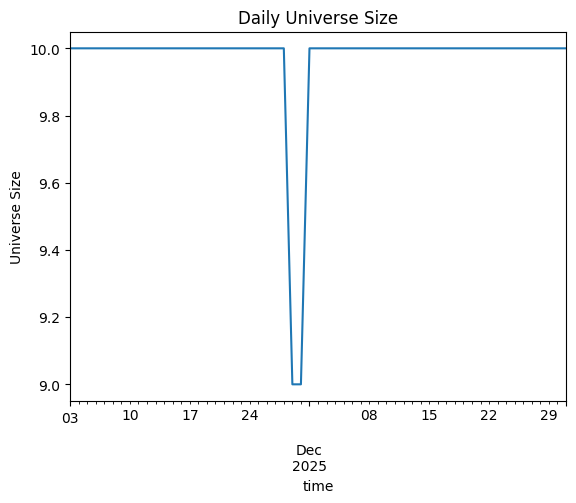

In [3]:
# Derive each insider trade's dollar volume from shares and price per share.
universe_history['dollarvolume'] = universe_history['shares'].fillna(0) * universe_history['pricepershare'].fillna(0)
# Count selected assets by day.
universe_size = universe_history.groupby(level=[0, 1]).count().dollarvolume.groupby(level=0).count()
print(f"Universe days: {len(universe_size)}")
# Store the selected symbol list.
unique_assets = list(universe_history.index.levels[1].unique())
print(f"Mean basket size per day: {universe_size.mean():.1f}")
print('')
print(universe_history.dollarvolume.describe().map('{:0.3f}'.format))
universe_size.plot(title='Daily Universe Size', ylabel='Universe Size');

### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close       high        low       open  \
symbol            time                                                     
ACT XOF4GF67NMG5  2025-11-04  35.325306  35.472904  34.848070  35.010428   
                  2025-11-05  35.896021  35.964900  34.518432  35.246586   
                  2025-11-06  35.354825  36.043620  35.335146  35.836981   
                  2025-11-07  36.151859  36.939052  34.420033  36.427376   
                  2025-11-08  36.407697  36.604495  35.246586  36.132179   
...                                 ...        ...        ...        ...   
MDLN YYDBHHPS742T 2025-12-25  44.280000  45.010000  43.550000  43.950000   
                  2025-12-27  44.085000  45.450000  43.610000  44.500000   
                  2025-12-30  42.090000  43.800000  41.735000  43.570000   
                  2025-12-31  41.820000  43.250000  41.620000  42.050000   
                  2026-01-01  42.000000  43.070000  41.210000  41.940000   

                                 volume  
symbol            time                   
ACT XOF4GF67NMG5  2025-11-04   235528.0  
                  2025-11-05   254701.0  
                  2025-11-06   385031.0  
                  2025-11-07   468045.0  
                  2025-11-08   322943.0  
...                                 ...  
MDLN YYDBHHPS742T 2025-12-25  4363660.0  
                  2025-12-27  8118252.0  
                  2025-12-30  5517778.0  
                  2025-12-31  4102917.0  
                  2026-01-01  5587994.0  

[12029 rows x 5 columns]

### Align Insider Volume And Returns

Build a joined table of insider dollar volume and future returns.

In [5]:
dataset = (
    universe_history.groupby(level=[0, 1]).agg(dollarvolume=('dollarvolume', 'sum')).rename_axis(['time', 'symbol'])
    .join(history.open.unstack('symbol').sort_index().pct_change(2, fill_method=None).shift(-2).stack().rename('futurereturn').rename_axis(['time','symbol']), how='inner')
)
dataset.head()

dollarvolume  futurereturn
time       symbol                                       
2025-11-04 HEI R735QTJ8XC9X   4.712320e+06     -0.020272
           HEIA RA5FTAI5HU91  4.712320e+06     -0.014425
           LLY R735QTJ8XC9X   2.280889e+07      0.051356
           LVS T4J5S7AT6WRP   1.371200e+07      0.026605
           NA YFMU9G55SB51    4.000012e+06     -0.046512

### Analyze Relationships Between Factor and Future Returns

Create a box plot of dollar-volume quantile buckets compared to future returns.

Factor: dollarvolume


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(-0.001, 22522.12]",1555.577,-17.98%,18.88%,0.21%,6.59%,76
1,"(22522.12, 763294.85]",272235.108,-15.24%,18.75%,0.43%,5.95%,75
2,"(763294.85, 3844281.616]",2042613.841,-17.73%,11.51%,-0.67%,5.09%,75
3,"(3844281.616, 14378512.0]",7201796.198,-10.94%,11.94%,0.53%,4.74%,75
4,"(14378512.0, 1098600014.19]",113600726.458,-29.27%,13.94%,-0.47%,5.32%,75


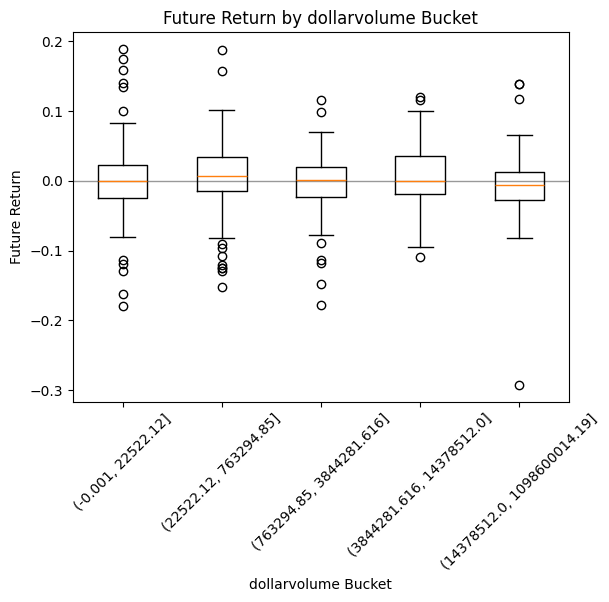

In [7]:
factor = 'dollarvolume'
# Split factor values into quantile buckets.
x = dataset[factor]
y = dataset['futurereturn']
buckets = pd.qcut(x, q=min(5, x.nunique()), duplicates='drop')
# Summarize each bucket with distribution statistics.
summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
    mean_factor=(factor, 'mean'),
    min_future_return=('futurereturn', 'min'),
    max_future_return=('futurereturn', 'max'),
    mean_future_return=('futurereturn', 'mean'),
    std_future_return=('futurereturn', 'std'),
    observations=('futurereturn', 'size')
).reset_index()
summary['bucket'] = summary['bucket'].astype(str)
# Display the bucket summary.
print(f"Factor: {factor}")
display(summary.style.format({
    'mean_factor': '{:.3f}',
    'min_future_return': '{:.2%}',
    'max_future_return': '{:.2%}',
    'mean_future_return': '{:.2%}',
    'std_future_return': '{:.2%}'
}))
# Plot the return distribution for each bucket.
groups = [y[buckets == b].values for b in buckets.cat.categories]
plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'Future Return by {factor} Bucket')
plt.xlabel(f'{factor} Bucket')
plt.ylabel('Future Return')
plt.xticks(rotation=45)
plt.show()